In [1]:
%pip install "qc-grader[qiskit,jupyter] @ git+https://github.com/qiskit-community/Quantum-Challenge-Grader.git"


  Cloning https://github.com/qiskit-community/Quantum-Challenge-Grader.git to /private/var/folders/l2/03q0yvcs4vxd3vv3tvt6034r0000gn/T/pip-install-dek_4snl/qc-grader_b9e557a200ca4603a535148769735743
  Running command git clone --filter=blob:none --quiet https://github.com/qiskit-community/Quantum-Challenge-Grader.git /private/var/folders/l2/03q0yvcs4vxd3vv3tvt6034r0000gn/T/pip-install-dek_4snl/qc-grader_b9e557a200ca4603a535148769735743
  Resolved https://github.com/qiskit-community/Quantum-Challenge-Grader.git to commit 1d7a6915623b0cfeac4c114391c279e9d98eb7f9
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


In [1]:
import qiskit
import qc_grader
print(f"Qiskit version: {qiskit.__version__}")
print(f"Grader version: {qc_grader.__version__}")

Qiskit version: 2.1.1
Grader version: 0.22.12


In [2]:
# Check that the account has been saved properly
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(name="qgss-2025")
service.saved_accounts()

{'default-ibm-cloud': {'channel': 'ibm_cloud',
  'url': 'https://cloud.ibm.com',
  'token': '202siqLmXAxw55XfOfseuslIZQoR9S92aSnONjEhNbca',
  'verify': True,
  'private_endpoint': False},
 'qgss-2025': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'mwlOvQ1IfMMT3cgwaqh2nnyza7iaLQDVf3tcllb9cDbv',
  'instance': 'crn:v1:bluemix:public:quantum-computing:us-east:a/6d204dcfffad466b8ae3587b57906c92:941a73da-dc04-4764-a1a8-af51057930ee::',
  'verify': True,
  'private_endpoint': False}}

In [5]:
# Import common packages first
import numpy as np

# Import qiskit classes
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

# Import utils and cosystems
from lab4_util import hamming_distance, minimum_distance, bring_states, matrixRank
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2  as Sampler

# Import grader
from qc_grader.challenges.qgss_2025 import (
    grade_lab4_ex1, 
    grade_lab4_ex2, 
    grade_lab4_ex3,
    grade_lab4_ex4,
    grade_lab4_ex5,
    grade_lab4_ex6
)

In [16]:
# Example usage:
str1 = "10110"
str2 = "11100"
dist = hamming_distance(str1, str2)
print(f"Hamming distance between '{str1}' and '{str2}' is: {dist}") # Output: 2

vec1 = [1, 0, 0, 1]
vec2 = [0, 0, 1, 1]
dist_vec = hamming_distance(vec1, vec2)
print(f"Hamming distance between {vec1} and {vec2} is: {dist_vec}") # Output: 2

Hamming distance between '10110' and '11100' is: 2
Hamming distance between [1, 0, 0, 1] and [0, 0, 1, 1] is: 2


In [17]:
# --- Example: A Simple [4, 3, 2] Parity Check Code ---
# This code takes 3 message bits (k=3) and adds an even parity bit
# to make the total codeword length n=4.
# Messages: 000, 001, 010, 011, 100, 101, 110, 111
# Codewords (adding even parity bit):
parity_code_4_3 = [
    "0000", # 000 + 0 (even parity)
    "0011", # 001 + 1
    "0101", # 010 + 1
    "0110", # 011 + 0
    "1001", # 100 + 1
    "1010", # 101 + 0
    "1100", # 110 + 0
    "1111"  # 111 + 1
]

# Calculate the minimum distance d
d_parity = minimum_distance(parity_code_4_3)
print(f"Codewords: {parity_code_4_3}")
print(f"Calculated minimum distance d = {d_parity}") # Output: 2

Codewords: ['0000', '0011', '0101', '0110', '1001', '1010', '1100', '1111']
Calculated minimum distance d = 2


In [18]:
# --- Example: [3, 1, 3] Repetition Code ---
repetition_code_3_1 = ["000", "111"]
d_repetition = minimum_distance(repetition_code_3_1)
print(f"Calculated minimum distance d = {d_repetition}") # Output: 3

# Capabilities for d=3:
t_detect = d_repetition - 1
t_correct = int((d_repetition - 1) / 2) // 1
print(f"Error Detection Capability (t_detect = d-1): {t_detect}") # Output: 2
print(f"Error Correction Capability (t_correct = floor((d-1)/2)): {t_correct}") # Output: 1

Calculated minimum distance d = 3
Error Detection Capability (t_detect = d-1): 2
Error Correction Capability (t_correct = floor((d-1)/2)): 1


In [19]:
test_str = "010"

print("Hamming distance between 010 and 000 is", hamming_distance(test_str, "000"))
print("Hamming distance between 010 and 111 is", hamming_distance(test_str, "111"))

Hamming distance between 010 and 000 is 1
Hamming distance between 010 and 111 is 2


In [9]:
hardcode_decoder_3_1_3 ={
    '000': '0',
    '001': '',
    '010': '',
    '011': '',
    '100': '',
    '101': '',
    '110': '',
    '111': '1'}

In [6]:
hardcode_decoder_bit_flip_syndrome_map = {
    # {"s1s0": "Error Code"}
    '00': 'I',   # No error
    '01': 'X2',  # Error on qubit 2
    '10': 'X0',  # Error on qubit 0
    '11': 'X1'   # Error on qubit 1
}




In [7]:
# Submit your answer using following code
grade_lab4_ex1(hardcode_decoder_bit_flip_syndrome_map )


Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [10]:
steane_decoder_syndrome_map = {
    '111000': 'X0',
    '011000': 'X1',
    '101000': 'X2',
    '001000': 'X3',
    '110000': 'X4',
    '010000': 'X5',
    '100000': 'X6',

    '111111': 'Y0',
    '011011': 'Y1',
    '101101': 'Y2',
    '001001': 'Y3',
    '110110': 'Y4',
    '010010': 'Y5',
    '100100': 'Y6',

    '000111': 'Z0',
    '000011': 'Z1',
    '000101': 'Z2',
    '000001': 'Z3',
    '000110': 'Z4',
    '000010': 'Z5',
    '000100': 'Z6',

    '000000': 'I'
}


In [11]:
# Submit your answer using following code
grade_lab4_ex2(steane_decoder_syndrome_map)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [36]:
def measure_steane_syndrome(qc, q_data, q_anc, c_reg):
    # Measure X-type Stabilizers (S0, S1, S2)
    qc.h(q_data)  # Hadamard on data qubits
    
    # S0: IIIXXXX
    qc.cx(q_data[0], q_anc[0])
    qc.cx(q_data[1], q_anc[0])
    qc.cx(q_data[2], q_anc[0])
    qc.cx(q_data[3], q_anc[0])
    
    # S1: IXXIIXX
    qc.cx(q_data[0], q_anc[1])
    qc.cx(q_data[1], q_anc[1])
    qc.cx(q_data[4], q_anc[1])
    qc.cx(q_data[5], q_anc[1])
    
    # S2: XIXIXIX
    qc.cx(q_data[0], q_anc[2])
    qc.cx(q_data[2], q_anc[2])
    qc.cx(q_data[4], q_anc[2])
    qc.cx(q_data[6], q_anc[2])
    
    qc.h(q_data)  # Undo Hadamard on data qubits
    qc.measure(q_anc[0:3], c_reg[0:3])  # Measure X syndrome
    qc.barrier()
    
    # Measure Z-type Stabilizers (S3, S4, S5)
    # No Hadamard on data qubits here, just CNOTs
    
    # S3: IIIZZZZ
    qc.cx(q_data[0], q_anc[3])
    qc.cx(q_data[1], q_anc[3])
    qc.cx(q_data[2], q_anc[3])
    qc.cx(q_data[3], q_anc[3])
    
    # S4: IZZIIZZ
    qc.cx(q_data[0], q_anc[4])
    qc.cx(q_data[1], q_anc[4])
    qc.cx(q_data[4], q_anc[4])
    qc.cx(q_data[5], q_anc[4])
    
    # S5: ZIZIZIZ
    qc.cx(q_data[0], q_anc[5])
    qc.cx(q_data[2], q_anc[5])
    qc.cx(q_data[4], q_anc[5])
    qc.cx(q_data[6], q_anc[5])
    
    qc.measure(q_anc[3:6], c_reg[3:6])  # Measure Z syndrome
    qc.barrier()


In [41]:
state = bring_states()

# Logical qubit (7 data qubits)
qr_data = QuantumRegister(7, name='q')
# Ancilla qubits for syndrome measurement (6)
qr_anc = QuantumRegister(6, name='anc')
# Classical registers for syndrome (initial & verify)
cr_initial_syn = ClassicalRegister(6, name='c_initial_syn')
cr_final_syn = ClassicalRegister(6, name='c_final_syn')

# Total circuit (13 qubits, 12 classical bits)
qc = QuantumCircuit(qr_data, qr_anc, cr_initial_syn, cr_final_syn)

# ---- TODO : Task 3 ---
# Initialize qc with the provided statevector on data qubits
qc.initialize(state, qr_data)
# --- End of TODO ---


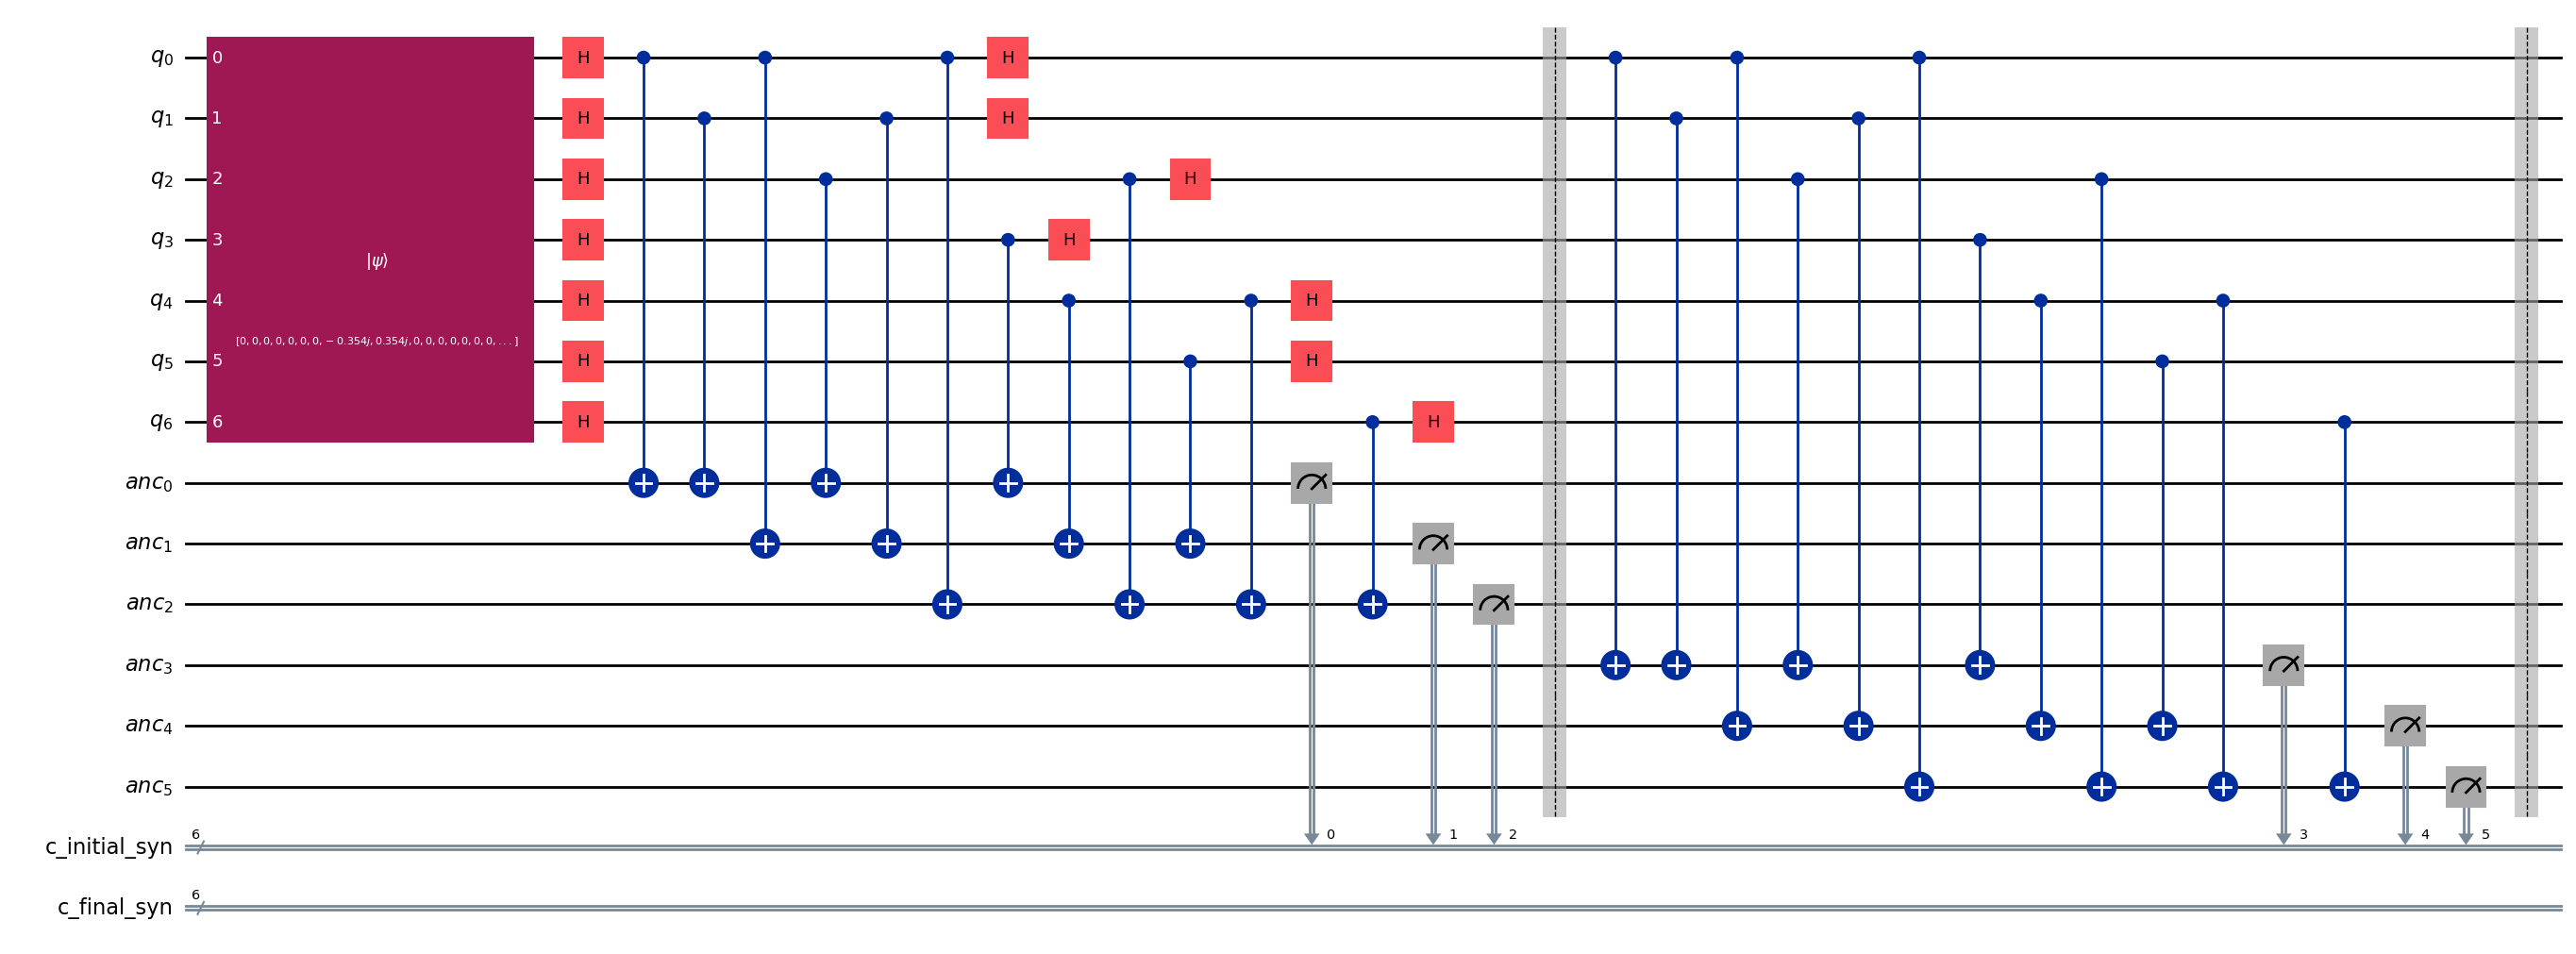

In [45]:
# --- AddSyndrome Measurement ---

measure_steane_syndrome(qc, qr_data, qr_anc, cr_initial_syn)

qc.draw('mpl', fold=-1)

In [46]:
# --- Run the Simulation using AerSimulator
backend = AerSimulator()

#make quantum circuit compatible to the backend
pm = generate_preset_pass_manager( backend = backend, optimization_level=3)
qc_isa = pm.run(qc)

#run and get counts
sampler = Sampler(mode=backend)
counts = sampler.run([qc_isa], shots = 10000).result()[0].data.c_initial_syn.get_counts()

# ---- TODO : Task 3 ---
# ---- TODO : Task 3 ---
most_common_syndrome = max(counts, key=counts.get)
error_code = steane_decoder_syndrome_map.get(most_common_syndrome, "Unknown")
# --- End of TODO ---

# --- End of TODO ---


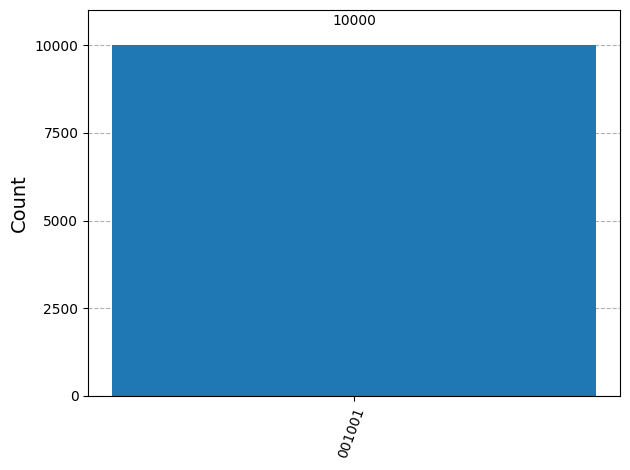

In [47]:
plot_histogram(counts)

In [48]:
# Submit your answer using following code
grade_lab4_ex3(error_code)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [120]:
import numpy as np

# We will define the parity check matrices for the toric code
HXtc = np.zeros((72, 144), dtype=int)  # initializing the matrices
HZtc = np.zeros((72, 144), dtype=int)

# We will ask you to modify the matrices by adding 1s in appropriate places
# As an example, we will show how to do so for the first few rows of the toric code

# ---- TODO : Task 4 ---

for j in range(72):
    # Calculate row and column indices for the 6x12 lattice (6 rows, 12 columns)
    row = j % 6
    col = j // 6

    # X-stabilizer (HXtc) - four qubits per stabilizer
    HXtc[j][j] = 1  # current qubit
    HXtc[j][6 * col + (row + 1) % 6] = 1  # next row, same column (periodic)
    HXtc[j][j + 72] = 1  # qubit in the second block (offset 72)
    HXtc[j][72 + 6 * ((col - 1) % 12) + row] = 1  # qubit in previous column, same row (periodic)

    # Z-stabilizer (HZtc) - four qubits per stabilizer
    HZtc[j][j] = 1  # current qubit
    HZtc[j][(row + 6 * col + 6) % 72] = 1  # qubit one row down (periodic)
    HZtc[j][j + 72] = 1  # qubit in second block
    HZtc[j][72 + 6 * col + (row - 1) % 6] = 1  # qubit one row up in second block (periodic)

# --- End of TODO ---


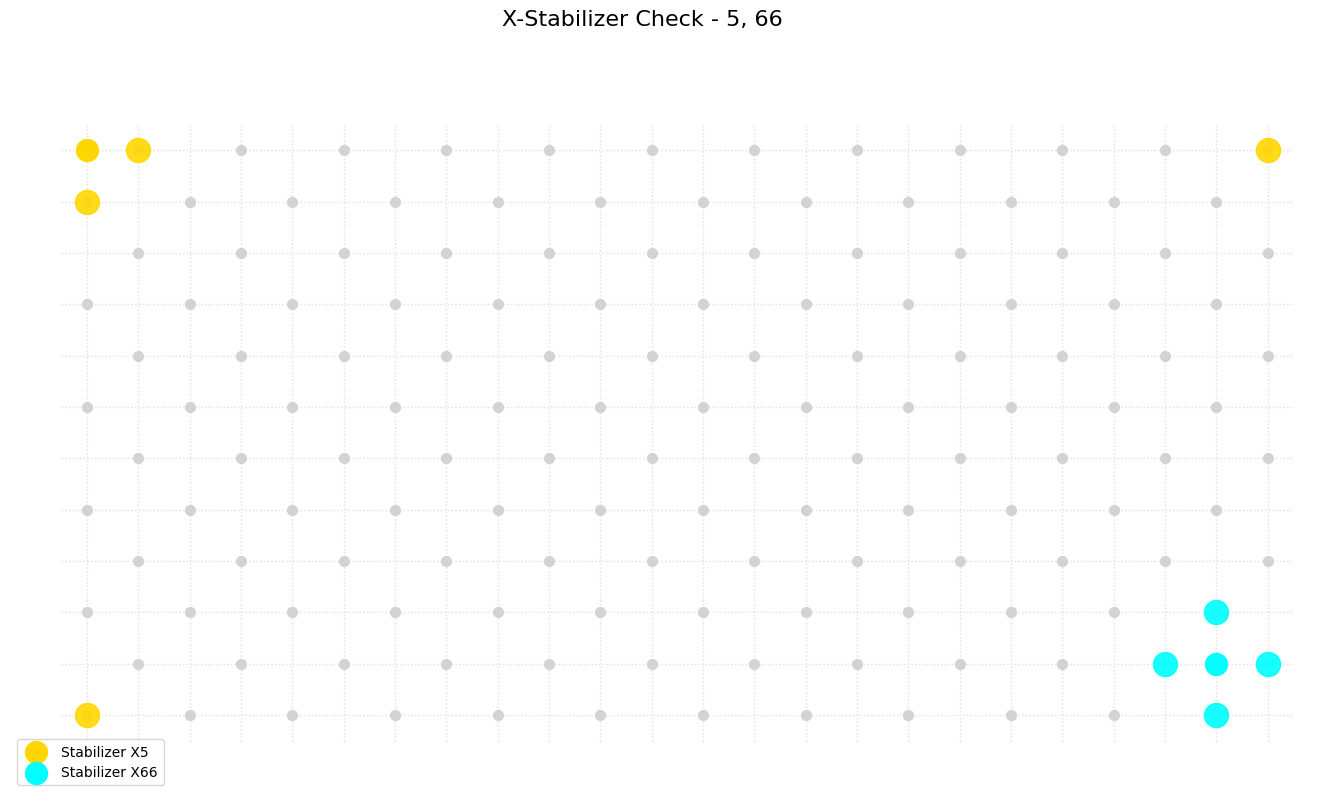

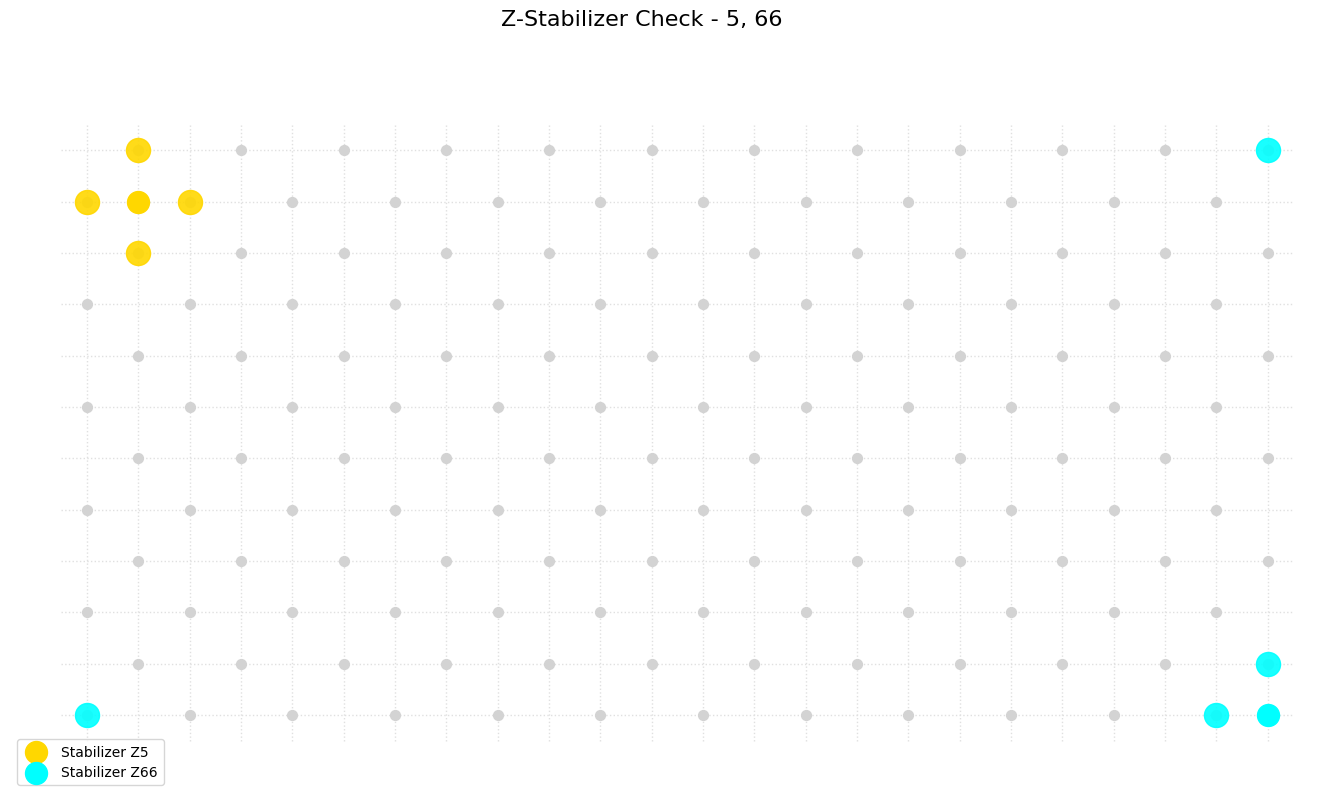

In [121]:
	
# Check the connectivity of HXtc and HZtc

from lab4_util import generate_stabilizer_plots
generate_stabilizer_plots(HXtc, HZtc)

In [118]:
# Submit your answer using following code
grade_lab4_ex4(HXtc, HZtc)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [59]:
# Check your submission status with the code below
from qc_grader.grader.grade import check_lab_completion_status

check_lab_completion_status("qgss_2025")

Lab 0: 2/2 exercises completed (100%)
    ✅ 2296 participants have completed this lab
Lab 1: 9/9 exercises completed (100%)
    ✅ 1776 participants have completed this lab
Lab 2: 7/7 exercises completed (100%)
    ✅ 1056 participants have completed this lab
Lab 3: 5/5 exercises completed (100%)
    ✅ 862 participants have completed this lab
Lab 4: 4/6 exercises completed (67%)
    ✅ 641 participants have completed this lab
Functions Labs: 0/8 exercises completed (0%)
    ✅ 4 participants have completed this lab


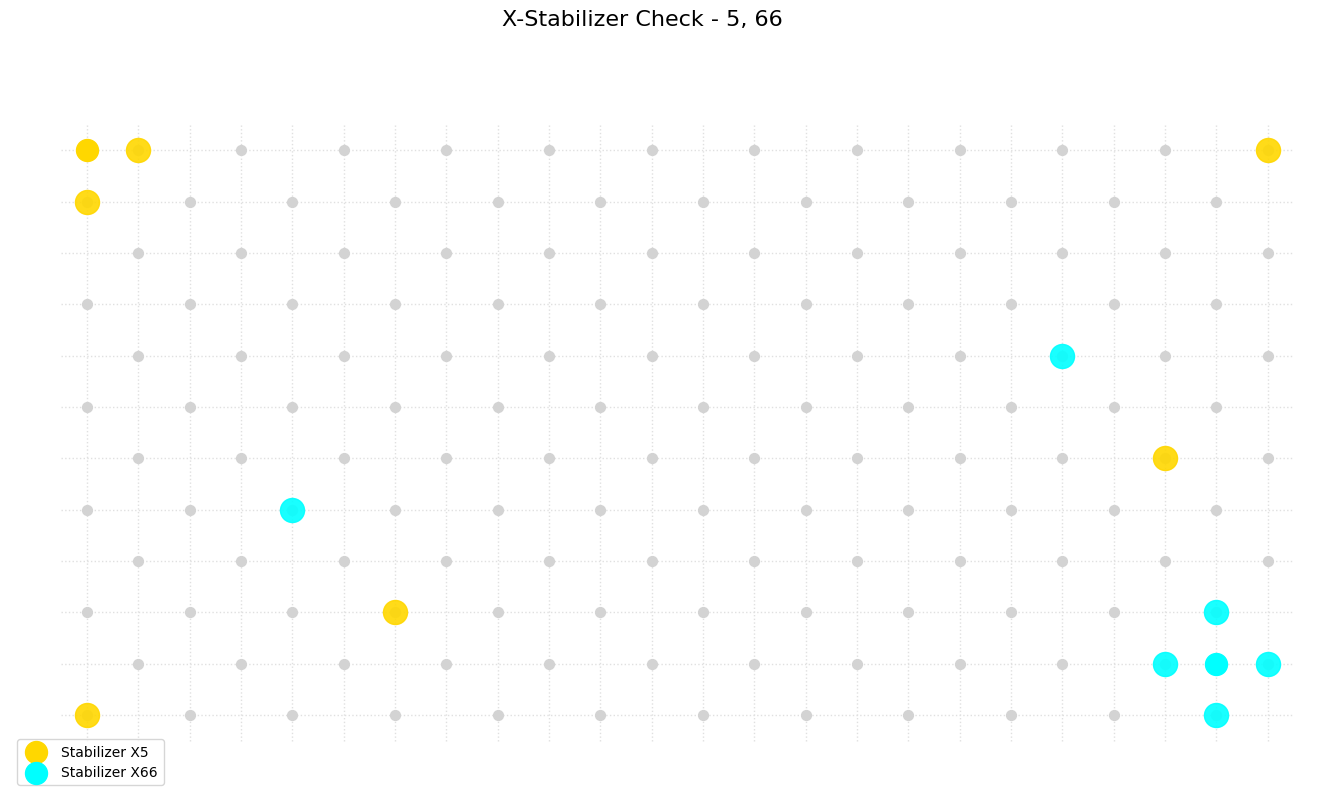

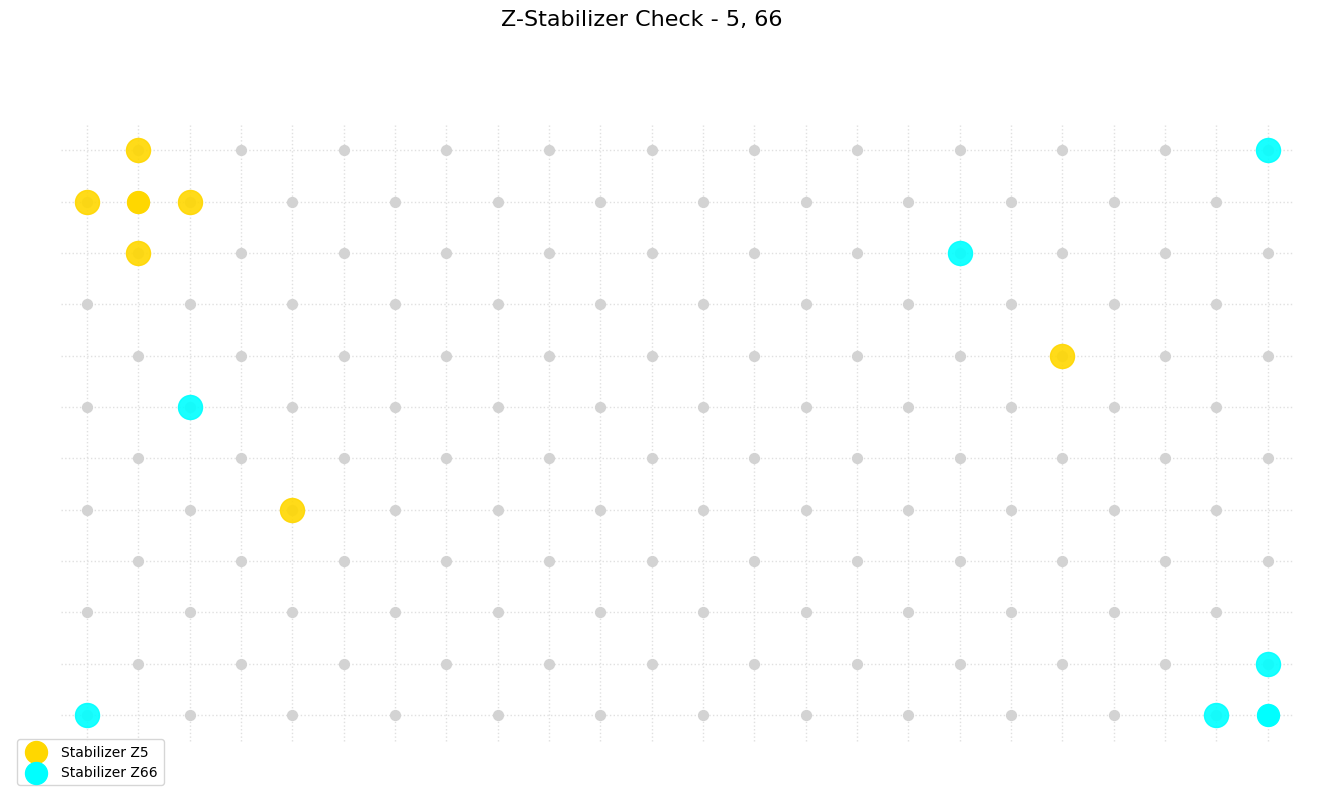

In [177]:
from lab4_util import generate_stabilizer_plots
generate_stabilizer_plots(HXgc, HZgc)

In [188]:
import numpy as np

HXgc = np.zeros((72, 144), dtype=int)
HZgc = np.zeros((72, 144), dtype=int)

# Set first row manually as given in the problem statement
HXgc[0][0] = 1
HXgc[0][1] = 1
HXgc[0][20] = 1
HXgc[0][72] = 1
HXgc[0][135] = 1
HXgc[0][138] = 1

HZgc[0][0] = 1
HZgc[0][6] = 1
HZgc[0][15] = 1
HZgc[0][72] = 1
HZgc[0][77] = 1
HZgc[0][130] = 1

for j in range(1, 72):
    row = j // 6
    col = j % 6
    
    # HXgc connections
    HXgc[j][j] = 1
    HXgc[j][6*row + (col + 1) % 6] = 1
    HXgc[j][((col + 2) % 6 + 6*((row + 3) % 12)) % 72] = 1
    HXgc[j][j + 72] = 1
    HXgc[j][72 + 6*((row - 2) % 12) + (col + 3) % 6] = 1
    HXgc[j][72 + 6*((row - 1) % 12) + col] = 1

    # HZgc connections
      # Nearest neighbors:
    HZgc[j][j] = 1
    HZgc[j][6 * ((row + 1) % 12) + col] = 1
    HZgc[j][6 * ((row + 2) % 12) + (col + 3) % 6] = 1
    HZgc[j][j + 72] = 1
    HZgc[j][72 + 6 * (row % 12) + (col + 5) % 6] = 1
    HZgc[j][72 + 6 * ((row + 9) % 12) + (col + 4) % 6] = 1


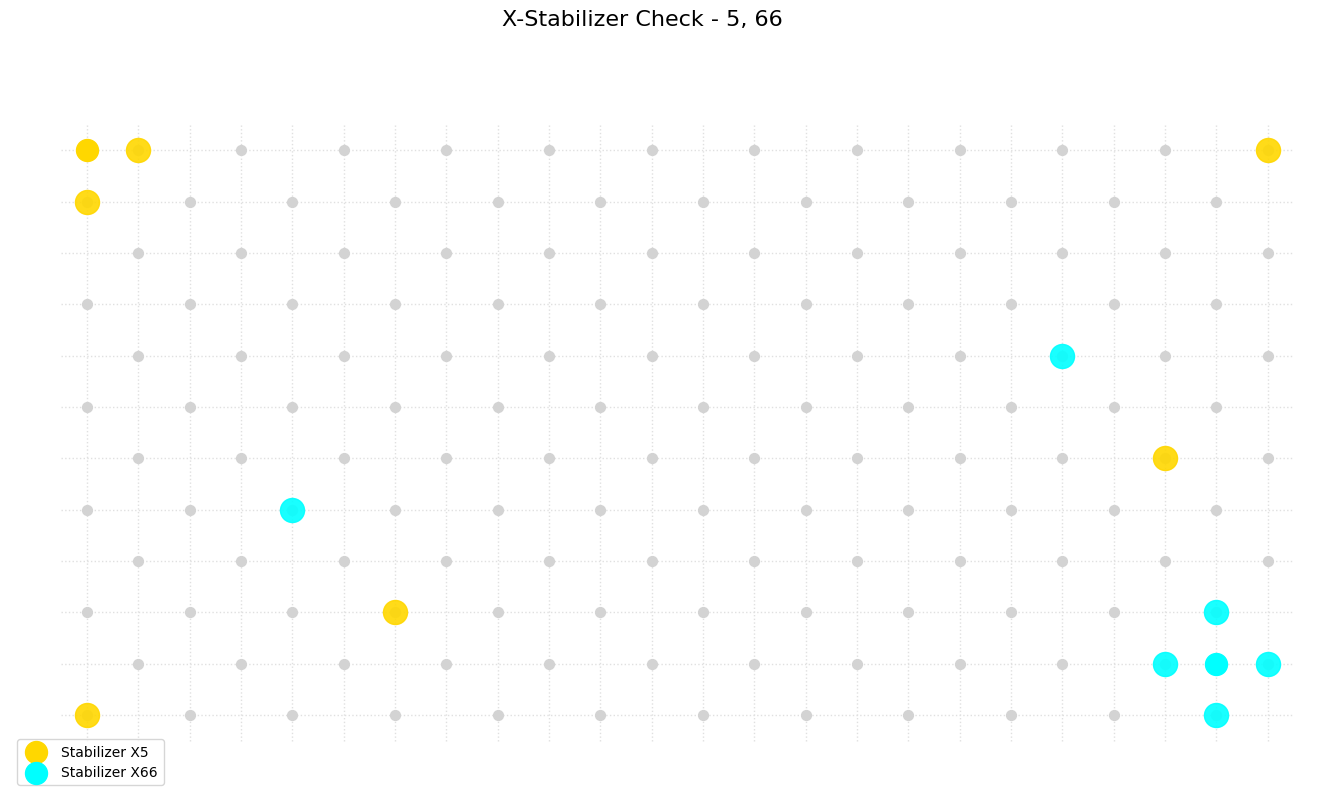

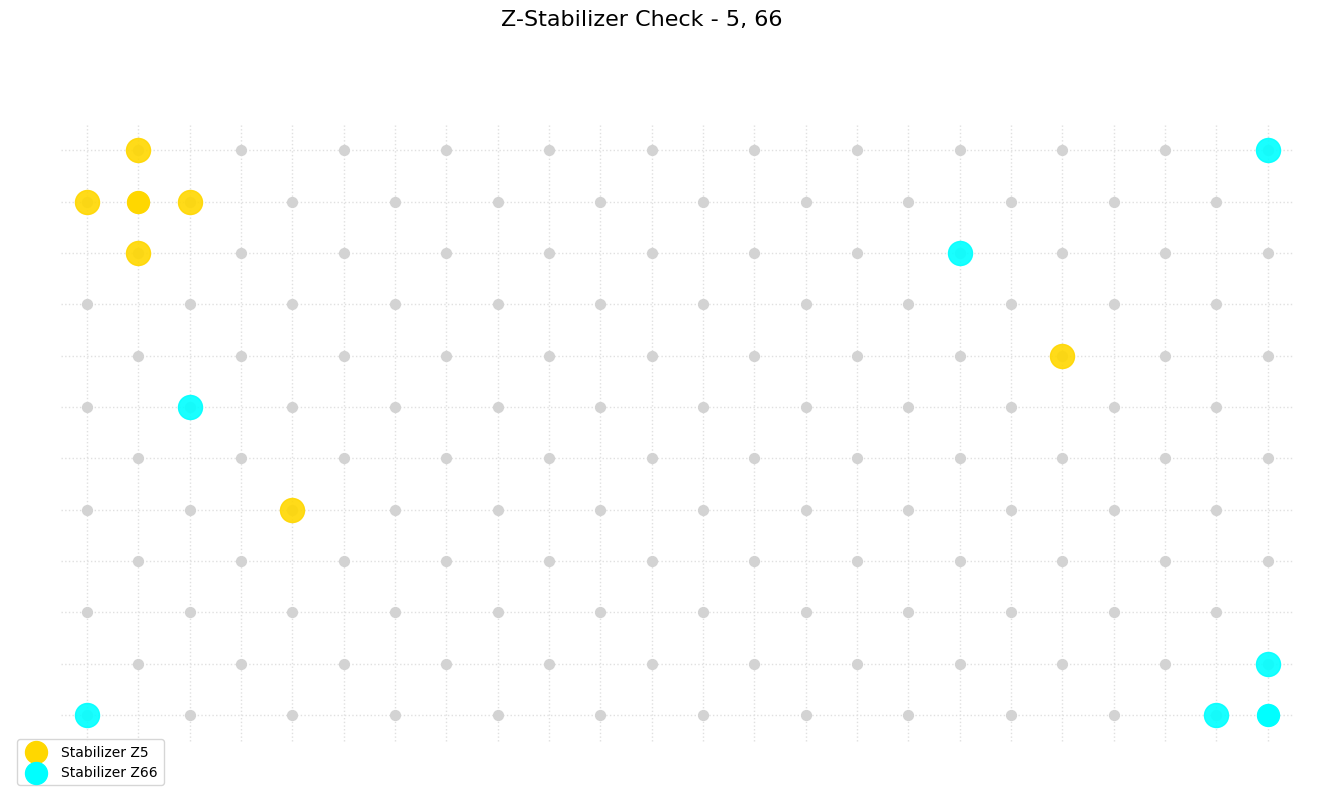

In [189]:
#Check stabilizer

generate_stabilizer_plots(HXgc, HZgc)

In [190]:
# Submit your answer using following code
grade_lab4_ex5(HXgc, HZgc)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [191]:
# ---- TODO : Task 6 ---
# Write code to calculate k_toric and k_gross
# Hint: You can use the matrixRank imported from lab4_util

from lab4_util import matrixRank

# Total number of data qubits
n = 144

# Toric code
rx_toric = matrixRank(HXtc)
rz_toric = matrixRank(HZtc)
k_toric = n - rx_toric - rz_toric

# Gross code
rx_gross = matrixRank(HXgc)
rz_gross = matrixRank(HZgc)
k_gross = n - rx_gross - rz_gross
# --- End of TODO ---

# Submit your answer using following code
grade_lab4_ex6(k_toric, k_gross)


Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [192]:
# Check your submission status with the code below
from qc_grader.grader.grade import check_lab_completion_status

check_lab_completion_status("qgss_2025")


Lab 0: 2/2 exercises completed (100%)
    ✅ 2305 participants have completed this lab
Lab 1: 9/9 exercises completed (100%)
    ✅ 1788 participants have completed this lab
Lab 2: 7/7 exercises completed (100%)
    ✅ 1069 participants have completed this lab
Lab 3: 5/5 exercises completed (100%)
    ✅ 874 participants have completed this lab
Lab 4: 6/6 exercises completed (100%)
    ✅ 657 participants have completed this lab
Functions Labs: 0/8 exercises completed (0%)
    ✅ 5 participants have completed this lab
